In [10]:
# Import libraries
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import statistics


from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score


import sklearn 
import sklearn.datasets
import sklearn.cross_decomposition
import sklearn.decomposition
import sklearn.neighbors
import sklearn.metrics

from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
from sklearn.preprocessing import StandardScaler

import ipympl

%matplotlib widget

file_path = 'preprocessed_combined_data_weekday_and_national_holiday_3-2022_3-2023.csv'

df = pd.read_csv(file_path)

df.set_index('Date Time', inplace=True)

display(df)

,kW,Nantum,Season,Altimeter reading,DP Temp (F),DB Temp (F),Heat_day,Cool_day,DP_12h,DB_12h,DP_24h,DB_24h,Weekday_0,Weekday_1,Weekday_2,Weekday_3,Weekday_4,Weekday_5,Weekday_6,National_holiday
Date Time,,,,,,,,,,,,,,,,,,,,
2022-03-24 00:00:00,121.500,0,0,30.11,16.0,58,0.072917,0.010417,14.0,72.0,24.0,61.0,0,0,0,1,0,0,0,0
2022-03-24 00:15:00,121.500,0,0,30.11,16.0,58,0.072917,0.010417,14.0,72.0,24.0,61.0,0,0,0,1,0,0,0,0
2022-03-24 00:30:00,119.248,0,0,30.11,16.0,58,0.072917,0.010417,14.0,72.0,24.0,61.0,0,0,0,1,0,0,0,0
2022-03-24 00:45:00,120.600,0,0,30.11,16.0,58,0.072917,0.010417,14.0,72.0,24.0,61.0,0,0,0,1,0,0,0,0
2022-03-24 01:00:00,123.300,0,0,30.11,16.0,56,0.093750,0.000000,12.0,74.0,23.0,58.0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-03-22 22:45:00,117.448,1,0,30.03,34.0,49,0.166667,0.000000,26.0,57.0,38.0,46.0,0,0,1,0,0,0,0,0
2023-03-22 23:00:00,115.200,1,0,30.03,34.0,50,0.156250,0.000000,24.0,57.0,38.0,45.0,0,0,1,0,0,0,0,0
2023-03-22 23:15:00,118.348,1,0,30.03,34.0,50,0.156250,0.000000,24.0,57.0,38.0,45.0,0,0,1,0,0,0,0,0


In [11]:
X3 = df.drop('kW',axis = 1)
y3 = df.kW

scaler = StandardScaler()
X3_scaled = scaler.fit_transform(X3)

X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.2, random_state=42)
# display(y3_test)

#kNN regression
from sklearn.neighbors import KNeighborsRegressor
# Create KNN classifier
knn = KNeighborsRegressor(n_neighbors = 3)
# Fit the classifier to the data
# lab_enc = preprocessing.LabelEncoder()
# encoded = lab_enc.fit_transform(y3_train)

# Need to convert to int for regressor to work
knn.fit(X3_train, np.ravel(y3_train))

from sklearn.model_selection import GridSearchCV
#create new a knn model
knn2 = KNeighborsRegressor()
#create a dictionary of all values we want to test for n_neighbors
param_grid = {'n_neighbors': np.arange(1, 25)}
#use gridsearch to test all values for n_neighbors
knn_gscv = GridSearchCV(knn2, param_grid, cv=5)
#fit model to data
knn_gscv.fit(X3_train, y3_train)

y3_predict_train = knn_gscv.predict(X3_train)
y3_predict_test = knn_gscv.predict(X3_test)

In [12]:
y3_train.info(())

y_train_sorted = y3_train.sort_index()
y_test_sorted = y3_test.sort_index()

<class 'pandas.core.series.Series'>
Index: 27954 entries, 2022-05-26 22:30:00 to 2022-09-04 12:45:00
dtypes: float64(1)
memory usage: 1.4+ MB


In [13]:
# # plot predicted vs actual values -- training data
# # Create Actual dataframe w/ sorted values
# y_train_sorted = y3_train.sort_index()
# y_test_sorted = y3_test.sort_index()

# # ax.plot(df_pred)

# # create prediction dataframe with index sorted
# df_pred = pd.DataFrame(y3_predict_train, columns=[['kW']])
# y_pred_train = df_pred.sort_index()

# df_pred_1 = y3_train.copy()
# df_pred = pd.DataFrame(y3_predict_train, columns=['kW'])
# df_pred_1['kW']=df_pred['kW'].values
# df_pred_2 = df_pred_1.sort_index()

# display(df_pred_1)
# display(df_pred_2)

# # plot actual vs prediction (time series)
# fig, ax = plt.subplots()
# ax.plot(y_train_sorted.index, y_train_sorted['kW'])  # actual data
# plt.xticks( rotation=45)

# plt.tight_layout()
# ax.plot(df_pred_2.index, df_pred_2['kW'])  # prediction 

{'n_neighbors': 1}
0.9468044943398072


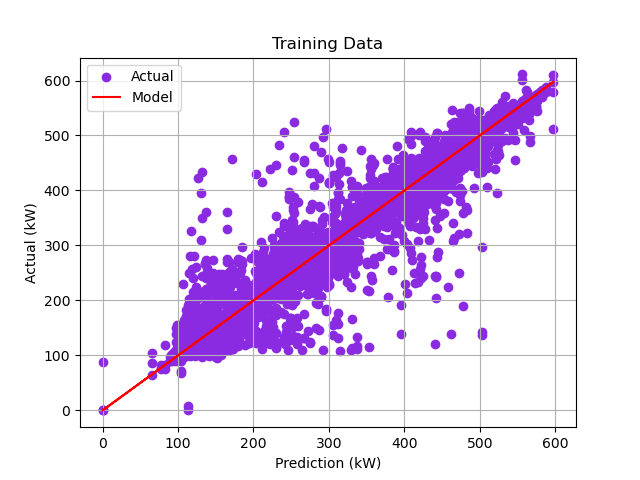

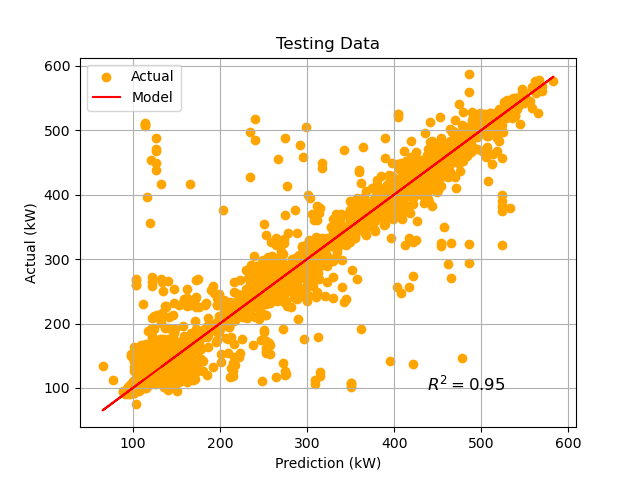

In [14]:
# kNN metrics, plot data vs predictions (training and testing)

#check top performing n_neighbors value
print(knn_gscv.best_params_)

#check mean score for the top performing value of n_neighbors
print(knn_gscv.best_score_)

fig, ax = plt.subplots()
ax.scatter(y3_predict_train,y3_train, c='blueviolet', label='Actual')
ax.plot(y3_predict_train, y3_predict_train, c="red", label='Model')
ax.set_xlabel('Prediction (kW)')
ax.set_ylabel('Actual (kW)')
ax.set_title('Training Data')
ax.legend()
ax.grid()

fig,ax = plt.subplots()
ax.scatter(y3_predict_test, y3_test, c='orange', label='Actual')
ax.plot(y3_predict_test, y3_predict_test, c="red", label='Model')
ax.set_xlabel('Prediction (kW)')
ax.set_ylabel('Actual (kW)')
ax.set_title('Testing Data')
r_squared = sklearn.metrics.r2_score(y3_test, y3_predict_test)
ax.annotate(f'$R^2 = {r_squared:.2f}$', xy=(0.7, 0.1), xycoords='axes fraction', fontsize=12)
ax.legend()
ax.grid()

In [15]:
# Error Evaluation 
# Training error 
print("Train R^2:", sklearn.metrics.r2_score(y3_train, y3_predict_train))
print("kNN root mean squared error: %.2f"
      % sklearn.metrics.mean_squared_error(np.ravel(y3_train), np.ravel(y3_predict_train), squared=False))
print("MAE:", mean_absolute_error(y3_train, y3_predict_train))
print("kNN CV value: ", (((statistics.stdev(np.ravel(y3_train) - np.ravel(y3_predict_train)))/statistics.mean(np.ravel(y3_train) - np.ravel(y3_predict_train)))))

# Test Error
print("\nTest R^2:", sklearn.metrics.r2_score(y3_test, y3_predict_test))
print("MAE:", mean_absolute_error(y3_test, y3_predict_test))
print("kNN root mean squared error: %.2f"
      % sklearn.metrics.mean_squared_error(np.ravel(y3_test), np.ravel(y3_predict_test), squared=False))
print("kNN CV value: ", (((statistics.stdev(np.ravel(y3_test) - np.ravel(y3_predict_test)))/statistics.mean(np.ravel(y3_test) - np.ravel(y3_predict_test)))))

Train R^2: 0.9778564739461396
kNN root mean squared error: 18.19
MAE: 6.239845031122559
kNN CV value:  633.932447989284

Test R^2: 0.9506892929173592
MAE: 9.630571469451997
kNN root mean squared error: 27.22
kNN CV value:  33.75207995739376
